<a href="https://colab.research.google.com/github/seelasairani7730-wq/Machine-Learning-Portfolio/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction using Linear Regression

1. Project Overview

### 📌 Problem Statement

The objective of this project is to predict the median house price based on various housing features such as median income, house age, average number of rooms, population, and location.

### 🎯 Goal

Develop a Linear Regression model that can accurately estimate house prices using the California Housing Dataset.

### 📊 Machine Learning Task

- Problem Type: Supervised Learning
- Category: Regression
- Algorithm: Linear Regression

### 🛠️ Technologies Used

- Python
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

### 📈 Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

2. Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

3. Load Dataset

### 📂 Dataset Information

For this project, we use the **California Housing Dataset** provided by Scikit-learn.

The dataset contains information about housing districts in California, including features such as:

- Median Income
- House Age
- Average Rooms
- Average Bedrooms
- Population
- Average Occupancy
- Latitude
- Longitude

### 🎯 Target Variable

The target variable is:

**Median House Value**

The goal is to predict the median house value using these housing features.

In [2]:
# Load the California Housing Dataset
housing = fetch_california_housing()

# Convert to a Pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = housing.target

# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


4. Exploratory Data Analysis

### 📊 Exploratory Data Analysis (EDA)

Before training a machine learning model, it is important to understand the dataset.

In this section, we will:

- Check the shape of the dataset
- View column names
- Identify data types
- Check for missing values
- Generate summary statistics

In [3]:
# Shape of the dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HouseValue'],
      dtype='object')

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HouseValue    float64
dtype: object


5. Data Cleaning

### 🔍 Missing Value Analysis

Missing values can affect the performance of machine learning models.

In this section, we will check whether any feature contains null values.

In [4]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64


In [5]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### 📈 Summary Statistics

Summary statistics provide an overview of the numerical features in the dataset, including:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles

In [6]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


6. Data Visualization

### 📊 Distribution of House Prices

This histogram shows how house prices are distributed in the California Housing dataset.

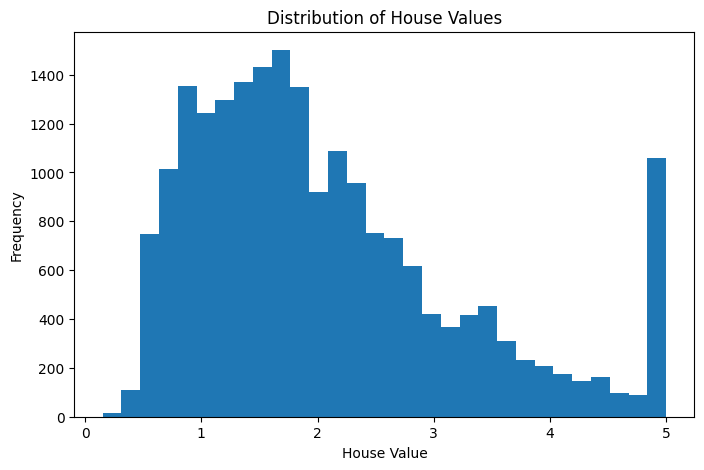

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["HouseValue"], bins=30)

plt.title("Distribution of House Values")
plt.xlabel("House Value")
plt.ylabel("Frequency")

# Save the graph
plt.savefig("distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### 🔥 Correlation Heatmap

A correlation heatmap helps us understand the relationship between different numerical features.

Correlation values range from:

- **+1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

This helps identify which features are most related to the target variable.

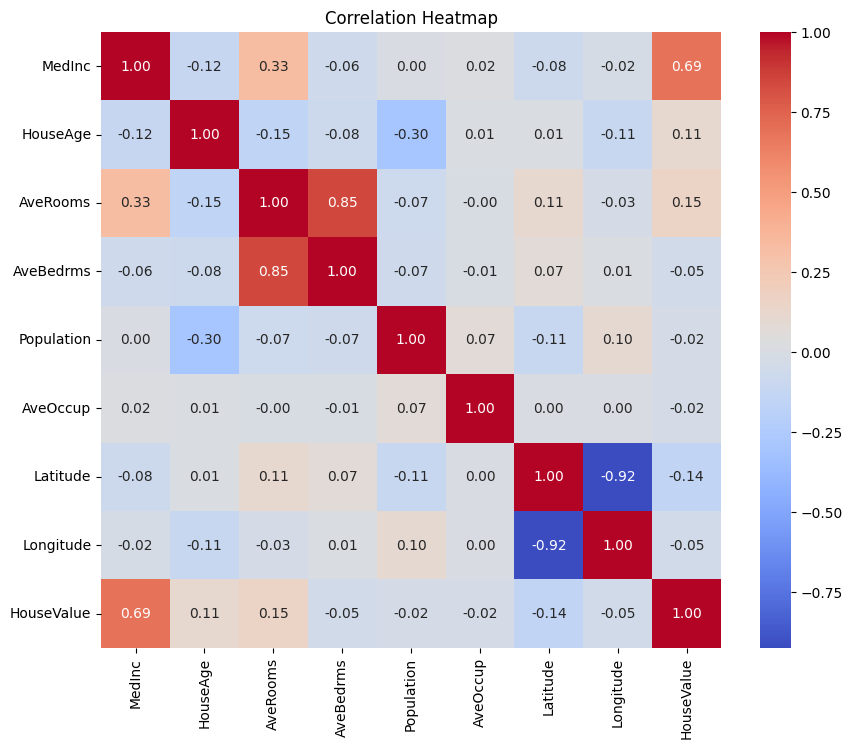

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

7. Data Preprocessing

## 7. Data Preprocessing

### 🎯 Objective

Before training the model, we separate the dataset into:

- Features (X)
- Target Variable (y)

The model learns patterns from the features to predict the target.

In [9]:
# Features (Independent Variables)
X = df.drop("HouseValue", axis=1)

# Target (Dependent Variable)
y = df["HouseValue"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (20640, 8)
Shape of y: (20640,)


8. Train/Test Split

## 8. Train/Test Split

### 🎯 Objective

The dataset is divided into training and testing sets.

- **Training Set:** Used to train the model.
- **Testing Set:** Used to evaluate how well the model performs on unseen data.

We use an 80:20 split, where 80% of the data is used for training and 20% for testing.

In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (16512, 8)
Testing Features : (4128, 8)
Training Target : (16512,)
Testing Target  : (4128,)


9. Train Linear Regression Model

## 9. Train Linear Regression Model

### 🎯 Objective

In this step, we train a Linear Regression model using the training dataset.

The model learns the relationship between the housing features and the house value.

Once training is complete, the model can predict house prices for new, unseen data.

In [11]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## 10. Make Predictions

After training, we use the model to predict house prices for the test dataset.

These predictions will later be compared with the actual values to evaluate the model.

In [12]:
# Predict house prices
y_pred = model.predict(X_test)

# Display first five predictions
print("First 5 Predictions:\n")
print(y_pred[:5])

First 5 Predictions:

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


10. Evaluate Model

## 10. Model Evaluation

### 🎯 Objective

After training the model, we evaluate its performance on the test dataset.

We use the following evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help us understand how well the model predicts house prices.

In [13]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("Model Evaluation Results")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------------
Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


In [14]:
# Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


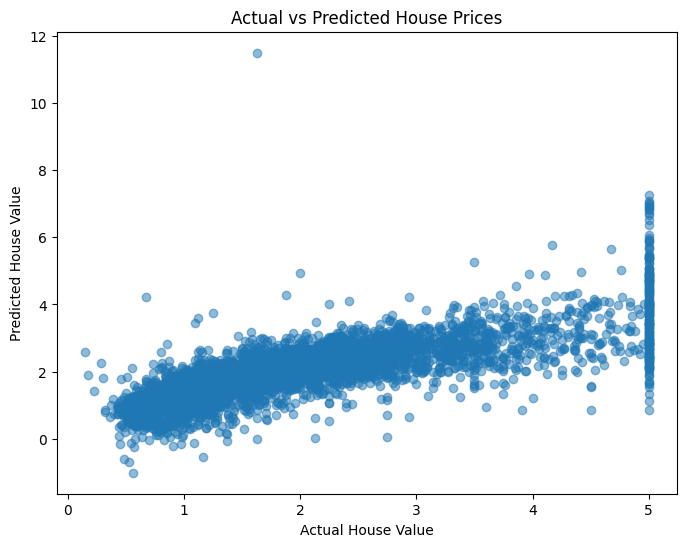

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")


plt.show()

11. Save Model

In [17]:
joblib.dump(model, "linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


 Feature Analysis

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


12. Conclusion

## 12. Conclusion

In this project, a Linear Regression model was developed to predict house prices using the California Housing dataset.

The model was trained on 80% of the data and evaluated on the remaining 20%.

### Results

- MAE: 0.5332
- RMSE: 0.7456
- R² Score: 0.5758

The model successfully captured the overall relationship between housing features and house prices. Although the performance is reasonable for a baseline model, more advanced algorithms such as Random Forest or XGBoost could improve prediction accuracy.

This project demonstrates the complete machine learning workflow, including data loading, exploratory data analysis, preprocessing, model training, evaluation, and model saving.